# Basic setting

### Measuring time

In [ ]:
!pip install --q ipython-autotime
%load_ext autotime

### Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
from keras.utils import to_categorical
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

# Data Collection

### Load data from Keras Library

In [ ]:
from keras.datasets import fashion_mnist

data = fashion_mnist.load_data()

# Data preparation

### Split: train, test

In [ ]:
(X_train, y_train), (X_test, y_test) = data
X_train.shape, y_train.shape, X_test.shape, y_test.shape

### Setting columns

In [ ]:
columns = ['T-shirt/top', 'Trouser',  'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

### Visualize the sampled images

In [ ]:
# np.random.seed(42)
sample = np.random.randint(60000, size=25)

fig = plt.figure(figsize=(8, 8))
for i, idx in enumerate(sample):
    plt.subplot(5, 5, i+1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.axis('off')
    plt.title(columns[y_train[idx]])
fig.tight_layout()
plt.show()

In [ ]:
pd.Series(y_train).value_counts().sort_index()

### Split: the training and validation.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

# Data preprocessing

### Min-Max Scaling

In [ ]:
X_train_s = X_train / 255.
X_val_s = X_val / 255.

X_train_s = X_train_s.reshape(-1, 28, 28, 1)
X_val_s = X_val_s.reshape(-1, 28, 28, 1)

X_train_s.shape, X_val_s.shape

### One-Hot Encoding

In [ ]:
y_train_o = to_categorical(y_train)
y_val_o = to_categorical(y_val)

y_train_o.shape, y_val_o.shape

# Model: CNN

### Create model

In [ ]:
from keras import layers

model = keras.Sequential([
    layers.Conv2D(filters=16, kernel_size=3, activation='relu',
                  input_shape=(28, 28, 1)),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Conv2D(filters=32, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model.summary()

### Visualize the model architecture

In [ ]:
plot_model(model, to_file='model.png', show_shapes=True, dpi=72)

### Compile model

In [ ]:
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=['accuracy'])

### History

In [33]:
EPOCHS = 30
BATCH_SIZE = 32

history = model.fit(X_train_s, y_train_o,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(X_val_s, y_val_o))


Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.7124 - loss: 0.7977 - val_accuracy: 0.8531 - val_loss: 0.4132
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8467 - loss: 0.4214 - val_accuracy: 0.8718 - val_loss: 0.3414
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8666 - loss: 0.3581 - val_accuracy: 0.8783 - val_loss: 0.3260
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8779 - loss: 0.3299 - val_accuracy: 0.8908 - val_loss: 0.2972
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8884 - loss: 0.3024 - val_accuracy: 0.8969 - val_loss: 0.2882
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8954 - loss: 0.2817 - val_accuracy: 0.9014 - val_loss: 0.2672
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9027 - loss: 0.2619 - val_accuracy: 0.9023 - val_loss: 0.2678
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9025 - loss: 0.2550 -

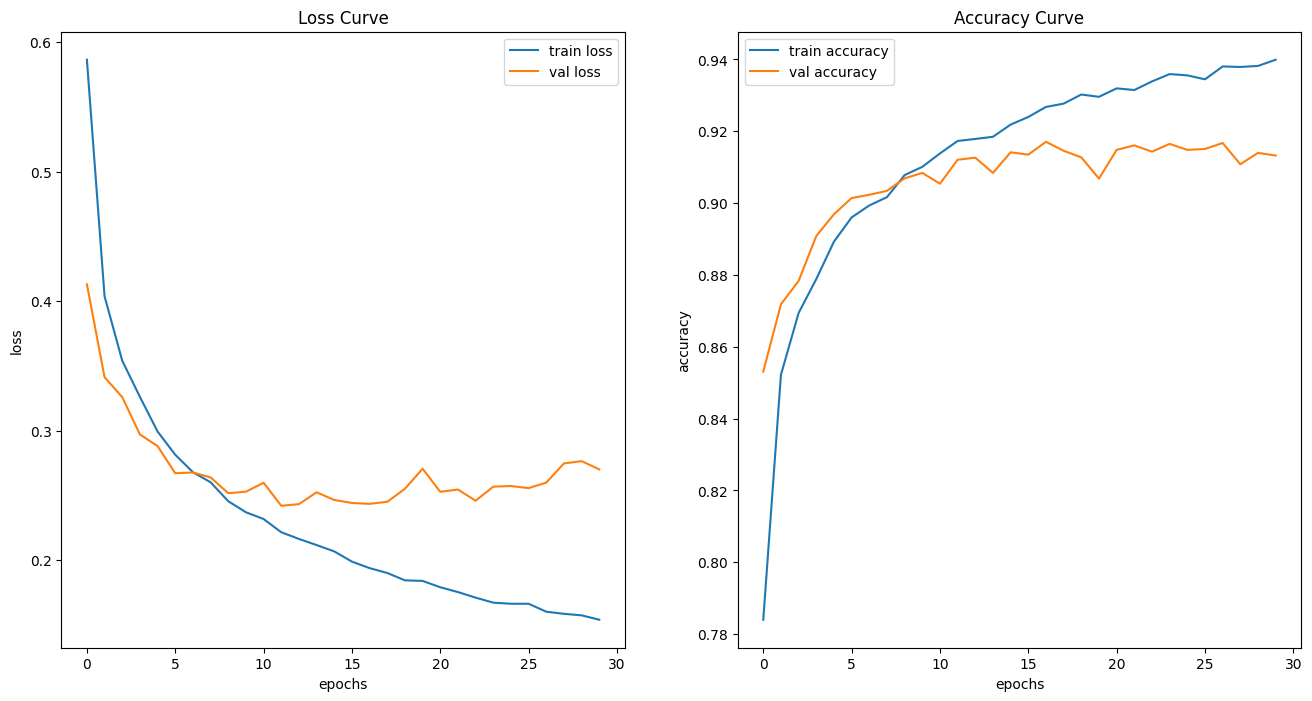

time: 485 ms (started: 2025-01-23 01:41:43 +00:00)


In [34]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(16, 8))
    plt.subplot(1, 2, 1)
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.plot(hist['epoch'], hist['loss'], label='train loss')
    plt.plot(hist['epoch'], hist['val_loss'], label='val loss')
    plt.title('Loss Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.xlabel('epochs')
    plt.ylabel('accuracy')
    plt.plot(hist['epoch'], hist['accuracy'], label='train accuracy')
    plt.plot(hist['epoch'], hist['val_accuracy'], label='val accuracy')
    plt.title('Accuracy Curve')
    plt.legend()
    plt.show()

plot_history(history)

# Evaluate

### One-hot Encoding

In [35]:
X_test_s = X_test / 255.
X_test_s = X_test_s.reshape(-1, 28, 28, 1)
y_test_o = to_categorical(y_test)

time: 29.1 ms (started: 2025-01-23 01:41:43 +00:00)


### Get prediction

In [36]:
y_pred = model.predict(X_test_s)

y_pred = np.argmax(y_pred, axis=1)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([9, 2, 1, ..., 8, 1, 5])

time: 1.67 s (started: 2025-01-23 01:41:43 +00:00)


accuracy: 0.9095
recall: 0.9094999999999999
precision: 0.9094561745691319
f1 : 0.9092859718141334


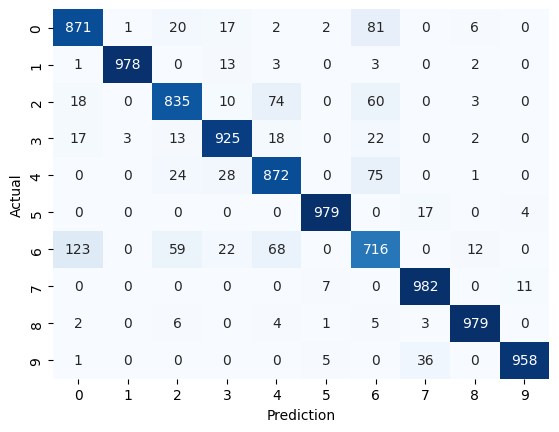

time: 273 ms (started: 2025-01-23 01:41:45 +00:00)


In [37]:
# Define a function to print metrics and display the confusion matrix
def print_metrics(y_true, y_pred, aver='binary'):
    print('accuracy:', accuracy_score(y_true, y_pred))
    print('recall:', recall_score(y_true, y_pred, average=aver))
    print('precision:', precision_score(y_true, y_pred, average=aver))
    print('f1 :', f1_score(y_true, y_pred, average=aver))

    # Plot the confusion matrix
    cfm = confusion_matrix(y_true, y_pred)
    s = sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    s.set(xlabel='Prediction', ylabel='Actual')
    plt.show()

# Print metrics for the test dataset
print_metrics(y_test, y_pred, aver='macro')


## 7.모델저장

In [38]:
model.save('cnn_muti_fashion.h5')

time: 38.9 ms (started: 2025-01-23 01:41:45 +00:00)


In [39]:
model.save('cnn_muti_fashion.keras')

time: 34.8 ms (started: 2025-01-23 01:41:45 +00:00)


In [40]:
model.save('cnn_muti_fashion')

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=cnn_muti_fashion.

time: 19.7 ms (started: 2025-01-23 01:41:45 +00:00)


In [ ]:
loaded_model = keras.saving.load_model('/content/cnn_muti_fashion.h5')

In [ ]:
loaded_model.summary()